# Data Visualization & Exploratory Data Analysis (EDA) Notebook

- Objective: Demonstrate Python coding for EDA and visualization

In [21]:
# Import core libraries
import pandas as pd      # For data manipulation
import numpy as np       # For numerical operations
import matplotlib.pyplot as plt  # For plotting
import seaborn as sns    # For advanced visualization
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

- We'll use a sample dataset for demonstration: the Titanic dataset
- You can replace this with your own dataset later (e.g., market or health data)

In [9]:
df = sns.load_dataset('titanic')  # Load sample dataset from Seaborn
df.head()  # Show first 5 rows

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Quick Overview

- Understanding the structure and basic info of the dataset

In [13]:
# Shape of the dataset
print("Dataset shape:", df.shape)

Dataset shape: (891, 15)


In [14]:
# Columns and data types
print("\nColumns and data types:")
print(df.dtypes)


Columns and data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [15]:
# Basic summary statistics for numerical columns
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


# Check Missing Values
- Missing values are common and should be handled before analysis




Missing values in each column:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


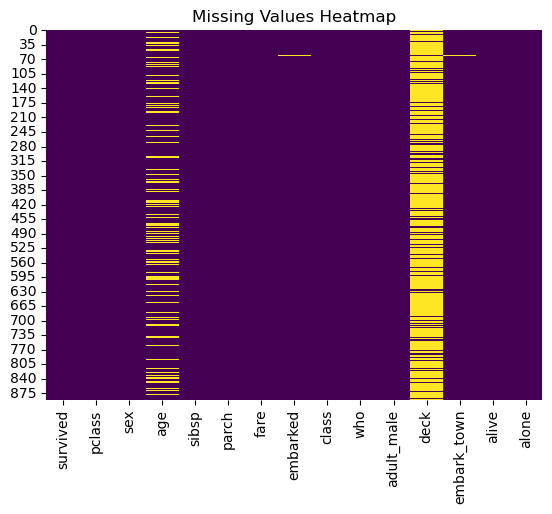

In [16]:
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Optional: Visualize missing values
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

#  Handling Missing Values
- We'll fill missing age values with median, and drop rows with missing embarked




In [23]:

# Fill missing age with median
df['age'].fillna(df['age'].median(), inplace=True)

In [24]:
# Drop rows where embarked is missing
df.dropna(subset=['embarked'], inplace=True)

In [25]:
# Check again
print("Missing values after handling:\n", df.isnull().sum())

Missing values after handling:
 survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64


# Detect Duplicates

In [26]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Drop duplicates if any
df.drop_duplicates(inplace=True)


Number of duplicate rows: 110


# Detect Outliers
- Using boxplot to detect outliers in the 'fare' column


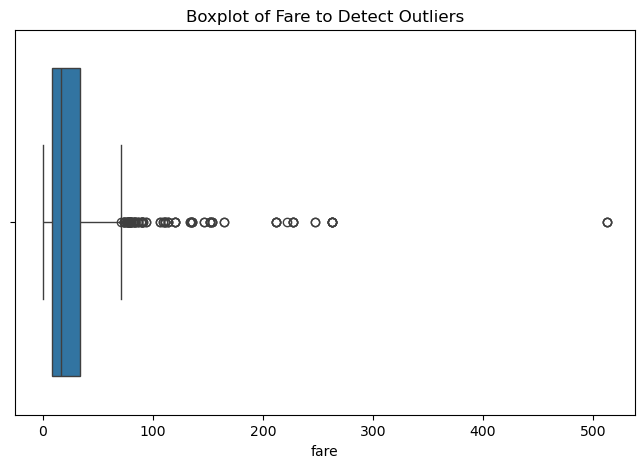

Number of outliers in 'fare': 101


In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['fare'])
plt.title("Boxplot of Fare to Detect Outliers")
plt.show()

# Optional: IQR method to detect outliers
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['fare'] < Q1 - 1.5*IQR) | (df['fare'] > Q3 + 1.5*IQR)]
print(f"Number of outliers in 'fare': {outliers.shape[0]}")

# Univariate Analysis
- Examining one variable at a time
- Example: Age distribution


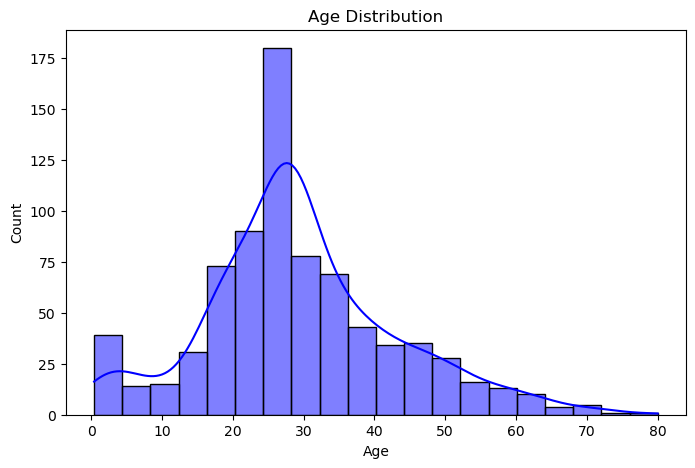

count    779.000000
mean      29.570501
std       13.729999
min        0.420000
25%       21.500000
50%       28.000000
75%       36.000000
max       80.000000
Name: age, dtype: float64


In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True, color='blue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Summary statistics for age
print(df['age'].describe())

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins = 20)

# Bivariate Analysis
- Examining relationship between two variables
- Example: Age vs Fare

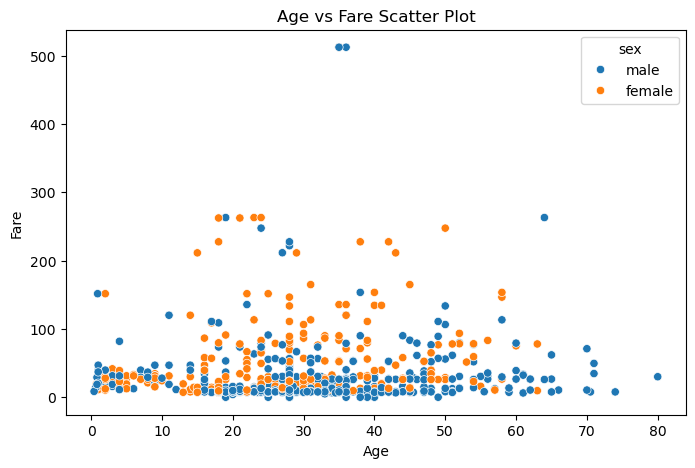

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='fare', data=df, hue='sex')
plt.title("Age vs Fare Scatter Plot")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

# Multivariate Analysis
- Pairplot shows relationships between multiple numerical variables

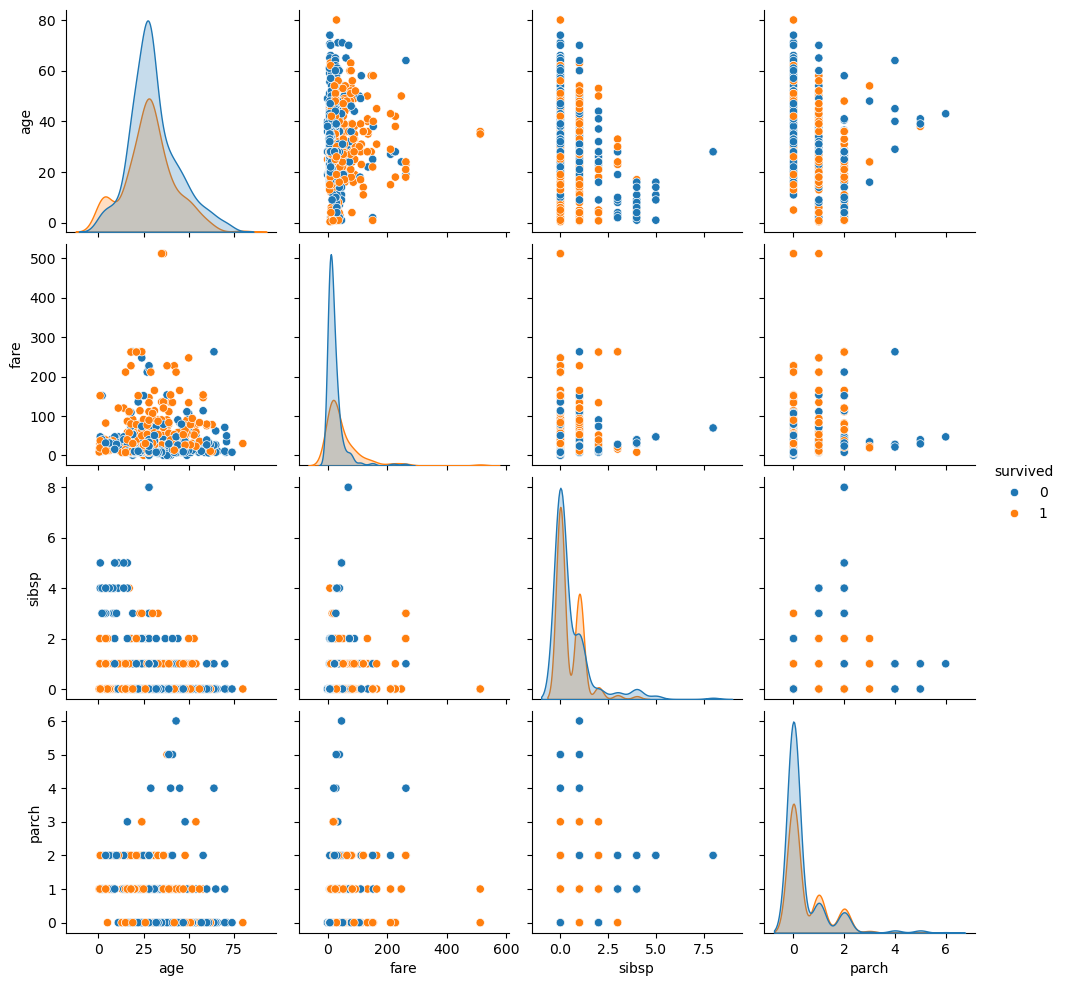

In [33]:
sns.pairplot(
    df[['age', 'fare', 'sibsp', 'parch', 'survived']],
    hue='survived',
    diag_kind='kde'
)
plt.show()

# Correlation Analysis
- Correlation matrix for numerical variables

In [36]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Display correlation values
correlation_matrix

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.327801,-0.084433,-0.036822,0.070509,0.244616
pclass,-0.327801,1.000000,-0.340148,0.088291,0.040335,-0.548405
age,-0.084433,-0.340148,1.000000,-0.278715,-0.182203,0.088700
sibsp,-0.036822,0.088291,-0.278715,1.000000,0.380385,0.136248
parch,0.070509,0.040335,-0.182203,0.380385,1.000000,0.193103
fare,0.244616,-0.548405,0.088700,0.136248,0.193103,1.000000


# Correlation Heatmap
- visualizing correlations using a heatmap

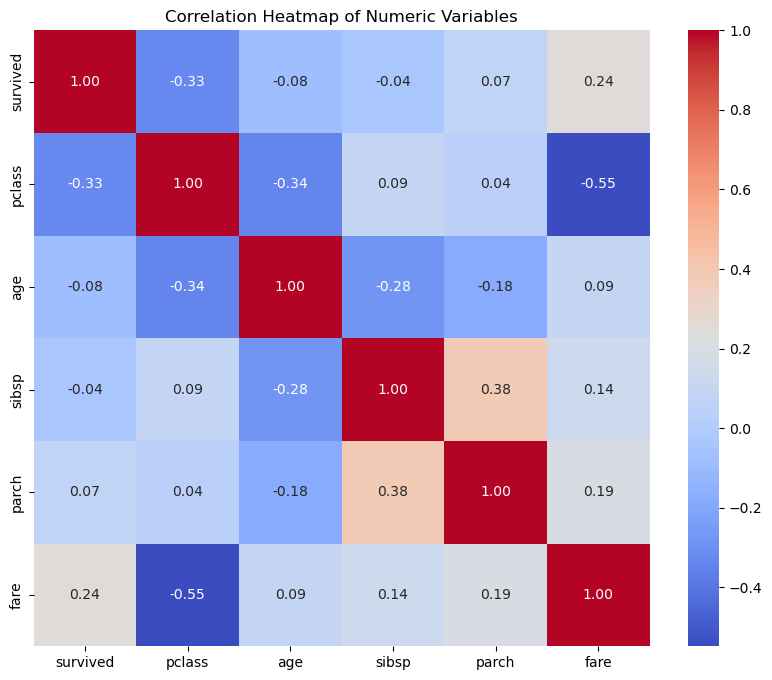

In [37]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Heatmap of Numeric Variables")
plt.show()


# Categorical Analysis
- Survival count by passenger class

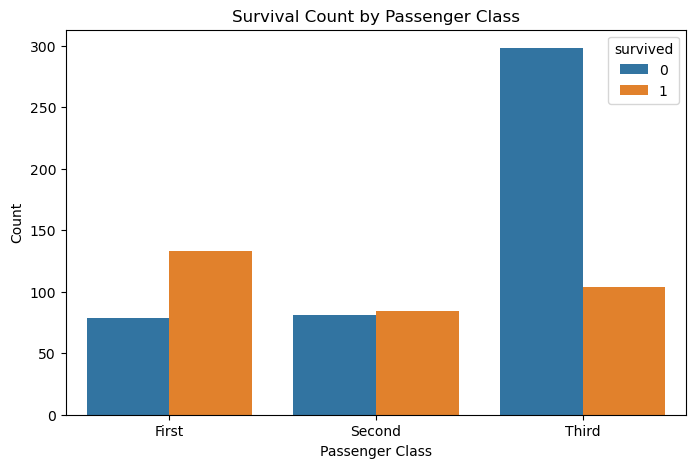

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(x='class', hue='survived', data=df)

plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

# Box Plot
- Fare distribution across passenger classes


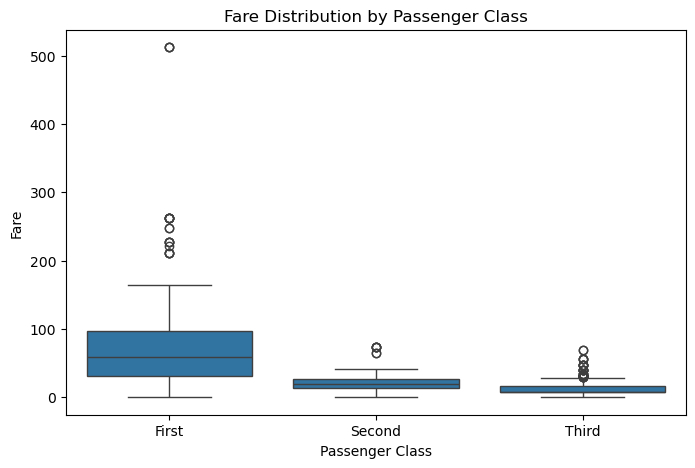

In [41]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='class', y='fare', data=df)

plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

# Plot Customization
- Demonstrating titles, labels, grids, and clarity


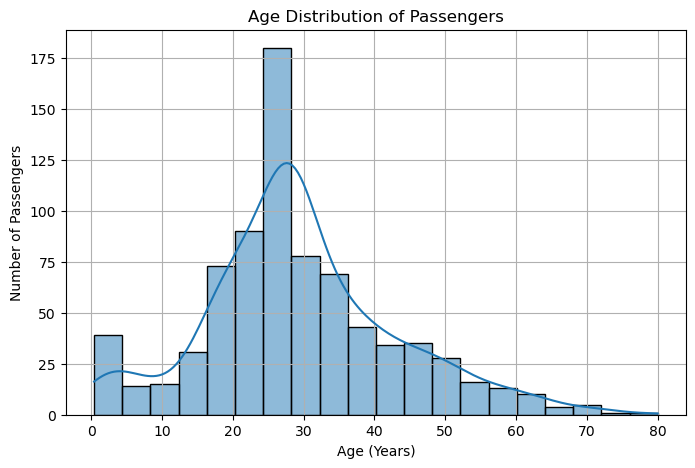

In [42]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Passengers")
plt.grid(True)
plt.show()
